In [5]:
!pip install pandas scikit-learn matplotlib

In [6]:
import pandas as pd

data = {
    "user": ["A", "A", "A", "B", "B", "A"],
    "time": [9, 10, 22, 9, 23, 3],
    "location": ["India", "India", "US", "India", "US", "Russia"]
}

df = pd.DataFrame(data)
df


,user,time,location
0,A,9,India
1,A,10,India
2,A,22,US
3,B,9,India
4,B,23,US
5,A,3,Russia


In [7]:
def detect_anomaly(row):
    if row["time"] < 6 or row["time"] > 22:
        return "Anomaly"
    if row["location"] != "India":
        return "Anomaly"
    return "Normal"

df["status"] = df.apply(detect_anomaly, axis=1)
df

,user,time,location,status
0,A,9,India,Normal
1,A,10,India,Normal
2,A,22,US,Anomaly
3,B,9,India,Normal
4,B,23,US,Anomaly
5,A,3,Russia,Anomaly


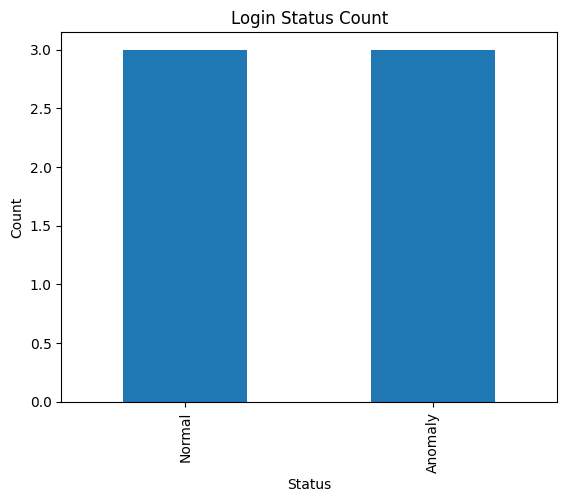

In [8]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")
plt.title("Login Status Count")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [9]:
!pip install scikit-learn


In [10]:
import pandas as pd

data = {
    "user": ["A", "A", "A", "B", "B", "A"],
    "time": [9, 10, 22, 9, 23, 3],
    "location": ["India", "India", "US", "India", "US", "Russia"]
}

df = pd.DataFrame(data)

# Convert location to numbers
df["location_code"] = df["location"].astype("category").cat.codes

# Use only numeric columns
X = df[["time", "location_code"]]

X

,time,location_code
0,9,0
1,10,0
2,22,2
3,9,0
4,23,2
5,3,1


In [13]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.3)

model.fit(X)

df["anomaly"] = model.predict(X)

df

,user,time,location,location_code,anomaly
0,A,9,India,0,1
1,A,10,India,0,1
2,A,22,US,2,1
3,B,9,India,0,1
4,B,23,US,2,-1
5,A,3,Russia,1,-1


In [14]:
df["status"] = df["anomaly"].apply(lambda x: "Anomaly" if x == -1 else "Normal")

df

,user,time,location,location_code,anomaly,status
0,A,9,India,0,1,Normal
1,A,10,India,0,1,Normal
2,A,22,US,2,1,Normal
3,B,9,India,0,1,Normal
4,B,23,US,2,-1,Anomaly
5,A,3,Russia,1,-1,Anomaly


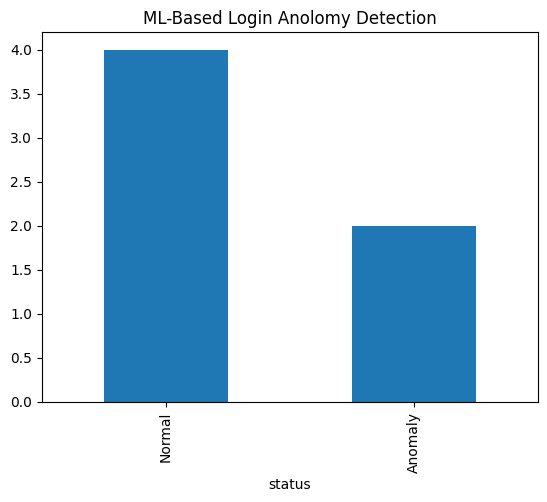

In [15]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")
plt.title("ML-Based Login Anolomy Detection")

plt.show()

In [16]:
import pandas as pd

data = {
    "user": ["A","A","A","B","B","A","C","C"],
    "time": [9,10,22,9,23,3,14,2],
    "location": ["India","India","US","India","US","Russia","India","China"],
    "device": ["Mobile","Mobile","Laptop","Mobile","Laptop","Desktop","Mobile","Desktop"]
}

df = pd.DataFrame(data)

# Convert categorical data
df["location_code"] = df["location"].astype("category").cat.codes
df["device_code"] = df["device"].astype("category").cat.codes

X = df[["time","location_code","device_code"]]
X

,time,location_code,device_code
0,9,1,2
1,10,1,2
2,22,3,1
3,9,1,2
4,23,3,1
5,3,2,0
6,14,1,2
7,2,0,0


In [17]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.3)
model.fit(X)

df["anomaly"] = model.predict(X)
df["status"] = df["anomaly"].apply(lambda x: "Anomaly" if x == -1 else "Normal")

df

,user,time,location,device,location_code,device_code,anomaly,status
0,A,9,India,Mobile,1,2,1,Normal
1,A,10,India,Mobile,1,2,1,Normal
2,A,22,US,Laptop,3,1,1,Normal
3,B,9,India,Mobile,1,2,1,Normal
4,B,23,US,Laptop,3,1,-1,Anomaly
5,A,3,Russia,Desktop,2,0,-1,Anomaly
6,C,14,India,Mobile,1,2,1,Normal
7,C,2,China,Desktop,0,0,-1,Anomaly


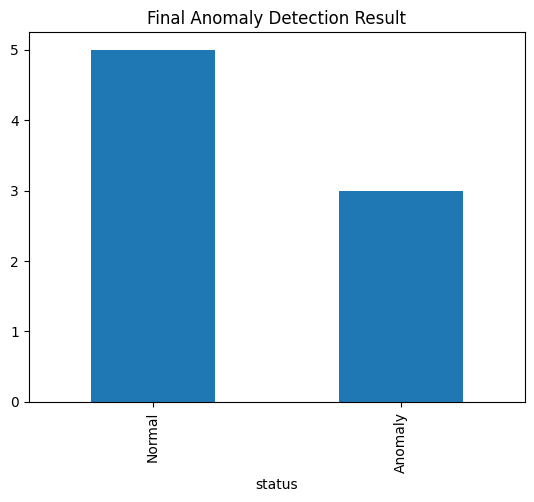

In [18]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")
plt.title("Final Anomaly Detection Result")
plt.show()